#Working with ALIVE.ipynb

by:
Danielle Losos (losos@wisc.edu),
Paul Stoy (pcstoy@wisc.edu),
Avanti Kekane (avkekane@wisc.edu),
Sophie Hoffman (shoffman22@wisc.edu),
Sadegh Ranjbar (sranjbar@wisc.edu),
& Ryan Abernathey (ryan@earthmover.io)

First: MAKE A COPY OF THIS NOTEBOOK!

File -> Save a copy in Drive -> Give this new copy a name that you like. If necessary, open the new file (located in the "Colab notebooks" folder in "My Drive")
Note: Colab will likely run best in Google Chrome.

This lesson will teach you how to work with [zarr](https://zarr.dev/) libraries created using [Icechunk](https://icechunk.io/en/latest/overview/#docs-organization) by [earthmover](https://earthmover.io/). We will use a zarr library that contains [Gross Primary Productivity (GPP) estimates](https://alive-abi.github.io/alive/daily-GPP.html) from the Advanced Baseline Imager Live Imaging of Vegetated Ecosystems ([ALIVE](https://alive-abi.github.io/alive/index.html)) workflow that we call 'ALIVE$_{GPP}$', also described in this [google slides presentation](https://docs.google.com/presentation/d/1PJclqluGFHkp9LpHZ85_pgL8lFLLaAMsQcEGZ2DIGSU/edit#slide=id.p1) that we created for the workshop.

To create ALIVE$_{GPP}$, we collected observations and data products from the [Advanced Baseline Imager](https://www.goes-r.gov/spacesegment/abi.html) on the [Geostationary Operational Environmental Satellites - R Series (GOES-R)](https://www.goes-r.gov/) from pixels that contain Ameriflux and NEON, Inc. towers as described in [Losos et al. (2024)](https://www.nature.com/articles/s41597-024-03071-z). We then used a machine learning model, specifically a gradient boosting model described in [Ranjbar et al. (2024)](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2024MS004341), to estimate GPP at the native temporal resolution of the ABI CONUS scene, every 5 minutes, as described in [Losos et al. (2025)](https://www.sciencedirect.com/science/article/pii/S0034425725001634).

The volume of data generated by sub-daily flux estimates is prohibitive for many conventional applications. We also want to create near-real time data products that we hope are useful for management, data assimilation, public outreach, and more. Honestly, cloud-native workflows help democratize science. More people can work with big data. For these reasons, zarr libraries are a logical choice.

First, import some of our favorite libraries. It can also help to turn off warnings.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#I like to set the matplotlib font size to something more readable
plt.rcParams.update({'font.size': 18})

from google.cloud import storage
import matplotlib.animation as animation
import datetime
from datetime import datetime, timedelta, date
import time
import warnings
warnings.filterwarnings("ignore")

We will also need to import the zarr experimental API from [os](https://docs.python.org/3/library/os.html), [xarray](https://docs.xarray.dev/en/stable/) to work with zarr files, and also [fsspec](https://filesystem-spec.readthedocs.io/en/latest/) because we'll be relying a bit on the [Google Cloud Platform](https://en.wikipedia.org/wiki/Google_Cloud_Platform).

In [ ]:
import os
os.environ['ZARR_V3_EXPERIMENTAL_API'] = '1'
import xarray as xr
import fsspec

For geospatial and climate data, [cartopy](https://scitools.org.uk/cartopy/docs/latest/) and [metpy](https://unidata.github.io/MetPy/latest/index.html) are necessary, and need to first be installed then imported into colab. You'll probably want to minimize the code cell outputs by clicking on the box/arrow button below the [code block](https://colab.research.google.com/notebooks/markdown_guide.ipynb).

In [ ]:
!pip install cartopy
!pip install metpy
import cartopy.crs as ccrs
import metpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 305.5/305.5 kB 21.2 MB/s eta 0:00:00


Now, we need to install Icechunk, which is an open-source transactional storage engine for interacting with array data stored in the cloud. In other words, Icechunk helps communicate with our ALIVE data which we keep stored in [Tigris object storage buckets](https://www.tigrisdata.com/docs/) (a type of s3 cloud object storage). We create anonymous credentials to access the public ALIVE data in a read-only mode. Now we can read all the data in the bucket, but cannot change the underlying data.

In [ ]:
!pip install icechunk>=0.2.0
import icechunk

In [ ]:
anon_tigris_credentials = icechunk.tigris_storage(
    bucket="tigris-alive",
    prefix="wc061gnx_ALIVE_v1_2024_icechunk", # Specific prefix for ALIVE_v1_2024 repo
    region='us-east-1',
    anonymous=True,
)
public_repo = icechunk.Repository.open(storage=anon_tigris_credentials,)
session = public_repo.readonly_session(branch="main")

Now we can open the GPP data for the whole year of 2024 as an xarray dataset. We can explore its contents and perform analyses.

In [ ]:
ds_2024 = xr.open_dataset(session.store,  group="daily_GPP_2024", engine="zarr", consolidated=False)
ds_2024

<xarray.Dataset> Size: 4TB
Dimensions:  (t: 70272, y: 1500, x: 2500)
Coordinates:
  * t        (t) datetime64[ns] 562kB 2024-01-01T00:02:00 ... 2024-12-31T23:5...
  * y        (y) float32 6kB 0.1282 0.1282 0.1281 ... 0.04438 0.04432 0.04427
  * x        (x) float32 10kB -0.1013 -0.1013 -0.1012 ... 0.0385 0.03856 0.03861
Data variables:
    GPP      (t, y, x) float64 2TB ...
    DQF      (t, y, x) float64 2TB ...

The dimensions of the zarr array are huge. With 1500 points in the y dimension and 2500 in the x, and 70272 slices as of the evening of July 8 when we changed the collection, there are 263,520,000,000 GPP estimates to work with. The 3-D zarr array can be thought of as a 'data cube'. Think of a 2-D map that displays the collected data including the x and the y dimensions. The zarr array has multiple 2-D maps stacked on top of each other with data collected at different times of the day. This is why the 3rd dimension is 't' for time.

In [ ]:
ds_2024.dims

FrozenMappingWarningOnValuesAccess({'t': 70272, 'y': 1500, 'x': 2500})

## Fixed Grid to Lat/Lon Functions

The following code blocks deal with shifting from the [Advanced Baseline Imager](https://www.goes-r.gov/spacesegment/abi.html) [fixed grid projection](https://www.star.nesdis.noaa.gov/atmospheric-composition-training/satellite_data_goes_imager_projection.php) to more common coordinates, and for accessing S3 buckets.

In [ ]:
H = 35786023.0 + 6378137.0 # perspective_point_height + semi_major_axis
req = 6378137 #semi_major_axis
rpol = 6356752.31414 # semi_minor_axis
e = 0.0818191910435, # GRS-80 eccentricity
lon_0_deg = -75.0 # GOES-16 sub-sat longitude

Currently, the zarr array x and y dimensions are not values of latitude and longitude. This is because the data collected from the GOES-R satellite 'curves' the view of Earth from the satellite's perspective. Because we need to utilize the data in latitude and longitude, we will convert these values.

In Python, one can define functions into which variables can be passed to return outputs. These two functions convert between the ABI fixed grid to latitude and longitude, and back again. They require constants from the code block above.

In [ ]:
def ABIangle2LonLat(x, y, H, req, rpol, lon_0_deg):
    '''This function finds the latitude and longitude (degrees) of point P
    given x and y, the ABI elevation and scanning angle (radians)'''

    # Intermediate calculations
    a = np.sin(x)**2 + ( np.cos(x)**2 * ( np.cos(y)**2 + ( req**2 / rpol**2 ) * np.sin(y)**2 ) )
    b = -2 * H * np.cos(x) * np.cos(y)
    c = H**2 - req**2

    rs = ( -b - np.sqrt( b**2 - 4*a*c ) ) / ( 2 * a ) # distance from satellite point (S) to P

    Sx = rs * np.cos(x) * np.cos(y)
    Sy = -rs * np.sin(x)
    Sz = rs * np.cos(x) * np.sin(y)

    # Calculate lat and lon
    lat = np.arctan( ( req**2 / rpol**2 ) * ( Sz / np.sqrt( ( H - Sx )**2 + Sy**2 ) ) )
    lat = np.degrees(lat) #*
    lon = lon_0_deg - np.degrees( np.arctan( Sy / ( H - Sx )) )

    return (lon,lat)

In [ ]:
def LonLat2ABIangle(lon_deg, lat_deg, z, H, req, rpol, e, lon_0_deg):
    '''This function finds the ABI elevation (y) and scanning (x) angles (radians) of point P,
    given a latitude and longitude (degrees)'''

    # Convert lat and lon from degrees to radians
    lon = np.radians(lon_deg)
    lat = np.radians(lat_deg)
    lon_0 = np.radians(lon_0_deg)

    # Geocentric latitude
    lat_geo = np.arctan( (rpol**2 / req**2) * np.tan(lat) )

    # Geocentric distance to point on the ellipsoid
    _rc = rpol / np.sqrt(1 - (e**2)*(np.cos(lat_geo)**2)) # this is rc if point is on the ellipsoid
    rc = _rc + z # this is rc if the point is offset from the ellipsoid by z (meters)

    # Intermediate calculations
    Sx = H - rc * np.cos(lat_geo) * np.cos(lon - lon_0)
    Sy = -rc * np.cos(lat_geo) * np.sin(lon - lon_0)
    Sz = rc * np.sin(lat_geo)

    # Calculate x and y scan angles
    y = np.arctan( Sz / Sx )
    x = np.arcsin( -Sy / np.sqrt( Sx**2 + Sy**2 + Sz**2 ) )

    return (x,y)

#  Make time-series line plot

A logical place to start with zarr arrays is to plot a single pixel in the time dimension. We'll choose the location of the WLEF tower that hosts the eddy covariance station [('US-PFa')](https://ameriflux.lbl.gov/sites/siteinfo/US-Pfa) in the center of the [CHEESEHEAD19 domain](http://co2.aos.wisc.edu/data/CHEESEHEAD-incoming/map/description.php).

In [ ]:
# Geographical coordinates of the WLEF tall tower
site_lon =  -90.2723
site_lat = 	45.9459
site_elev = 470 #m

start_date = pd.to_datetime('2024-07-04')
end_date = pd.to_datetime('2024-07-05')

In [ ]:
# Convert point lat/lon to ABI Fixed grid scan angles
x_rad, y_rad = LonLat2ABIangle(site_lon,site_lat,site_elev, H,req,rpol,0.0818191910435,lon_0_deg)
print(x_rad,y_rad)

-0.03066547447917786 0.11984619954627368


In [ ]:
# Extract the time series data for the selected point
date_mask = (ds_2024['t'] >= start_date) & (ds_2024['t'] <= end_date)

oneDay = ds_2024.sel(t=slice(start_date, end_date))
gpp_timeseries = oneDay.sel(x=x_rad, y=y_rad, method='nearest')

The data looks a bit better with a half-hour cadence, so we can use xarray's [resample](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.resample.html) function to group the data in 30-minute increments and compute the mean.

In [ ]:
ds_daily = gpp_timeseries.resample(t='30min').mean()

With *ds_daily* resampled, we can plot the values to visualize the change in GPP over time in this location.

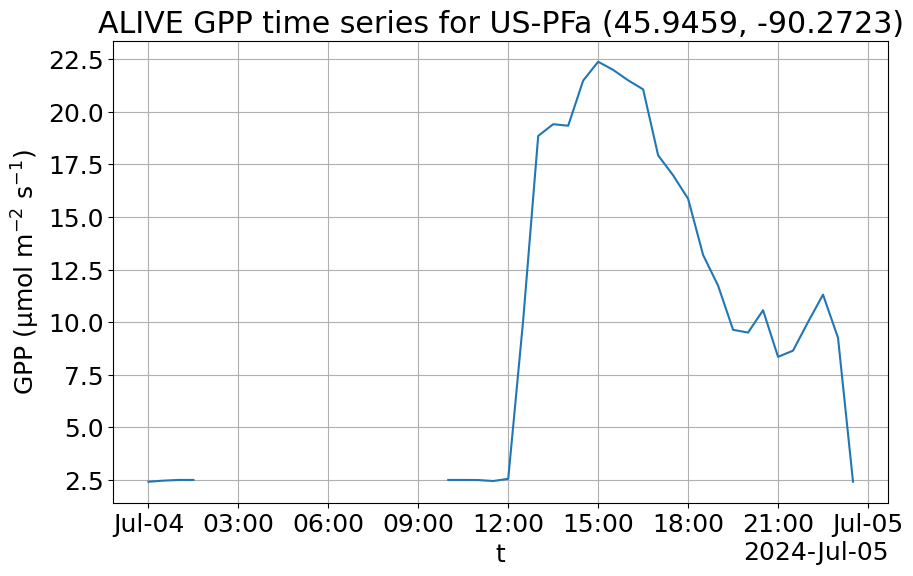

In [ ]:
plt.figure(figsize=(10, 6))
ds_daily['GPP'].plot()
plt.title(f'ALIVE GPP time series for US-PFa ({site_lat}, {site_lon})')
plt.ylabel('GPP (μmol m$^{-2}$ s$^{-1})$')
plt.grid(True)
plt.show()

You may notice some errors: GPP should be zero when there is no sunlight, however, the plot shows non-zero GPP values at night. These issues have since been corrected.

We can also plot individual ALIVE$_{𝐺𝑃𝑃}$  images that correspond to a single zarr library 'slice' in time. An image from the 4$^{𝑡ℎ}$  of July is a great place to start.

In [ ]:
from datetime import datetime, timedelta

year = 2024
day_of_year = 186  # July 4 (2024 is a leap year)
hour = 18  # UTC time is noon Central Standard Time
minute = 2  # ABI scans times are at 2,7,12,17,27,...57 mins after the hour

dt = datetime(year, 1, 1) + timedelta(days=day_of_year -1, hours=hour, minutes=minute)

print(f"The converted datetime is: {dt}")

GPPimage = oneDay.sel(t=dt)

The converted datetime is: 2024-07-04 18:02:00


ALIVE takes advantage of Google Cloud, which makes it convenient to grab ABI imagery from the Google Cloud Platform to use its geographic information for plotting. ALIVE$_{GPP}$ uses the same coordinate projection. [fsspec](https://filesystem-spec.readthedocs.io/en/latest/) helps us do that while avoiding downloads to keep the workflow in the cloud and cartopy and metpy help with projections.

In [ ]:
# Get an ABI image from Google Cloud Storage. This is just a random image with a CONUS projection.
url = "https://storage.googleapis.com/gcp-public-data-goes-16/ABI-L2-BRFC/2022/164/16/OR_ABI-L2-BRFC-M6_G16_s20221641656172_e20221641658545_c20221641700372.nc"
#Use fsspec to stream image directly from Google Cloud Storage without downloading it locally
fp2 = fsspec.open(url)
brfImg = xr.open_dataset(fp2.open(), engine="h5netcdf", mask_and_scale=True)

#Use cartopy and metpy to parse its geographic projection information
data = brfImg.metpy.parse_cf('BRF1')
geostationary = data.metpy.cartopy_crs

# Sweep the ABI data from the x (north/south) and y (east/west) axes
x = data.x
y = data.y

Creating individual images benefits from cartopy features like U.S. States, coastlines, and more. Note the use of '{}'.format(dt) for adding the timestamp to the header and the MATLAB-type syntax of matplotlib for details like fontweight='bold', fontsize=15.

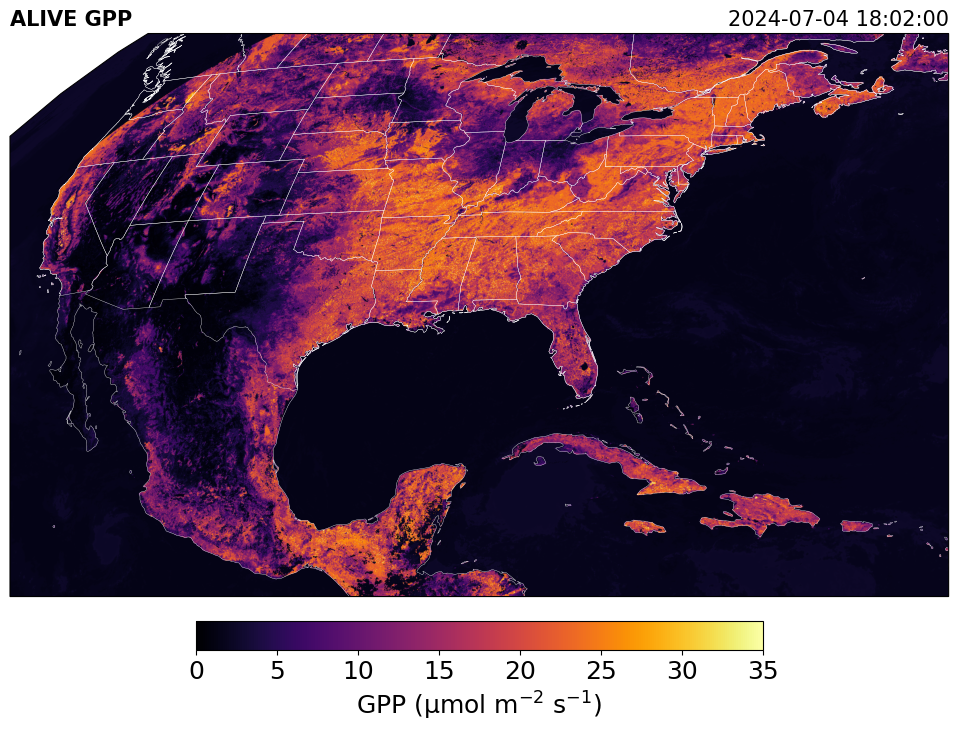

In [ ]:
# Use the geostationary projection to plot the image on a map
# This method stretches the image across a map with the same projection and dimensions as the data

fig = plt.figure(figsize=(15, 8))

# Create axis with Geostationary projection
ax = fig.add_subplot(1, 1, 1, projection=geostationary)

# Add the ALIVE GPP image to the figure. The data is in the same projection as the axis created
# Extract the data variable you want to plot from the GPPimage Dataset.
# Assuming the data variable is named 'GPP', replace 'GPP' with the actual variable name if different.
im = ax.imshow(GPPimage['GPP'].values, origin='upper', cmap=plt.cm.inferno, vmin=0, vmax=35,
          extent=(x.min(), x.max(), y.min(), y.max()),
          transform=geostationary)

# Add coastlines and states
ax.coastlines(resolution='50m', color='white', linewidth=0.25)
ax.add_feature(ccrs.cartopy.feature.STATES, edgecolor='white', linewidth=0.25)

#Add title
plt.title('ALIVE GPP', loc='left', fontweight='bold', fontsize=15)
plt.title('{}'.format(dt), loc='right', fontsize=15)
cb = fig.colorbar(im, label='GPP (μmol m$^{-2}$ s$^{-1}$)', orientation='horizontal', fraction=0.046, pad=0.04)

plt.show()

We can also zoom in; let's choose latitude and longitude boundaries that approximate the U.S. Midwest & Great Lakes region.

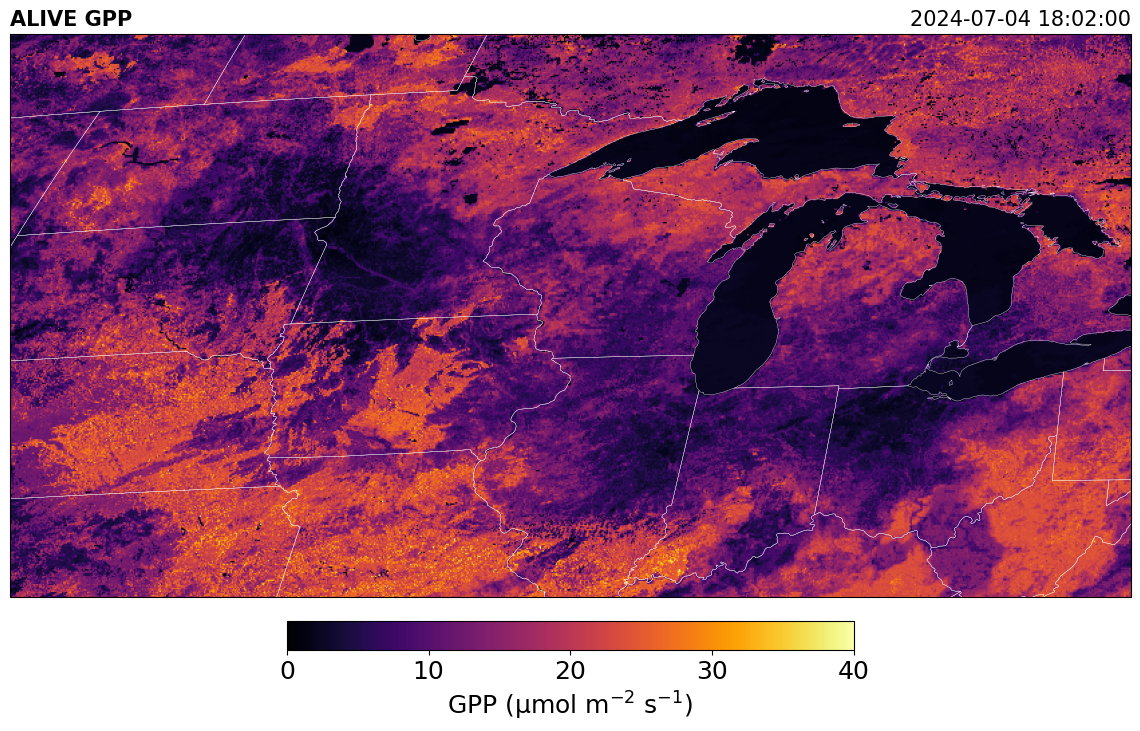

In [ ]:
# Dimensions of the frame
fig_size_width = 15
fig_size_height = 8

# Latitude and longitude extents of the frame
lat_west = -100
lat_east = -80
lon_south = 38
lon_north = 50

# Use the geostationary projection to plot the image on a map
# This method streches the image across a map with the same projection and dimensions as the data

fig = plt.figure(figsize=(15, 8))

# Create axis with Geostationary projection
ax = fig.add_subplot(1, 1, 1, projection=geostationary)

# Add the ALIVE GPP image to the figure. The data is in the same projection as the axis created
im = ax.imshow(GPPimage['GPP'], origin='upper', cmap=plt.cm.inferno, vmin = 0, vmax = 40,
          extent=(x.min(), x.max(), y.min(), y.max()),
          transform=geostationary)

ax.set_extent([lat_west, lat_east, lon_south, lon_north], crs=ccrs.PlateCarree())

# Add coastlines and states
ax.coastlines(resolution='50m', color='white', linewidth=0.25)
ax.add_feature(ccrs.cartopy.feature.STATES, edgecolor= 'white', linewidth=0.25)

#Add title
plt.title('ALIVE GPP', loc='left', fontweight='bold', fontsize=15)
plt.title('{}'.format(dt), loc='right',fontsize=15)
cb = fig.colorbar(im, label='GPP (μmol m$^{-2}$ s$^{-1}$)', orientation='horizontal', fraction=0.046, pad=0.04)

plt.show()

# Create an ALIVE Loop

Individual images and sums are great to look at, but it can be more exciting to visualize by creating loops. To do so, first specify dates and dimensions (if subsetting to regions).

In [ ]:
year = 2024
start_doy = 186 # JULIAN day
stop_doy = 186 # JULIAN day
start_hour = 18 # UTC time
end_hour = 20 # UTC time

# Latitude and longitude extents of the frame
lat_west = -100
lat_east = -80
lon_south = 38
lon_north = 50

#Set start date and times for loop and extract the 24 timestamps from the dataset
start_dt = pd.to_datetime(f"{year}-01-01") + pd.DateOffset(days= start_doy - 1, hours=start_hour)
stop_dt = pd.to_datetime(f"{year}-01-01") + pd.DateOffset(days= stop_doy - 1, hours= end_hour)
date_mask = (ds_2024['t'] >= start_dt) & (ds_2024['t'] <= stop_dt)
oneDay = ds_2024['GPP'][date_mask]

print(f"The loop will run from {start_dt} to {stop_dt} UTC")

The loop will run from 2024-07-04 18:00:00 to 2024-07-04 20:00:00 UTC


We need somewhere for the video to go. Mounting google drive to colab gives it that place (while staying in the cloud).

In [ ]:
# Mount your Google Drive to Colab to save the video
from google.colab import drive
cg = '/content/drive'
drive.mount(cg)

#You may need to choose a different path
path = '/content/drive/MyDrive/'
loopName = 'Fourth_of_July'

Mounted at /content/drive


The loop takes a few minutes, and should create an animation that demonstrates some of the clouds that passed over the US-xUN study area and the western Great Lakes region around local noon on the 4$^{th}$ of July.

2024-07-04 18:02:00
2024-07-04 18:07:00
2024-07-04 18:12:00
2024-07-04 18:17:00
2024-07-04 18:22:00
2024-07-04 18:27:00
2024-07-04 18:32:00
2024-07-04 18:37:00
2024-07-04 18:42:00
2024-07-04 18:47:00
2024-07-04 18:52:00
2024-07-04 18:57:00
2024-07-04 19:02:00
2024-07-04 19:07:00
2024-07-04 19:12:00
2024-07-04 19:17:00
2024-07-04 19:22:00
2024-07-04 19:27:00
2024-07-04 19:32:00
2024-07-04 19:37:00
2024-07-04 19:42:00
2024-07-04 19:47:00
2024-07-04 19:52:00
2024-07-04 19:57:00
VIDEO
2.1999798019727073 minutes


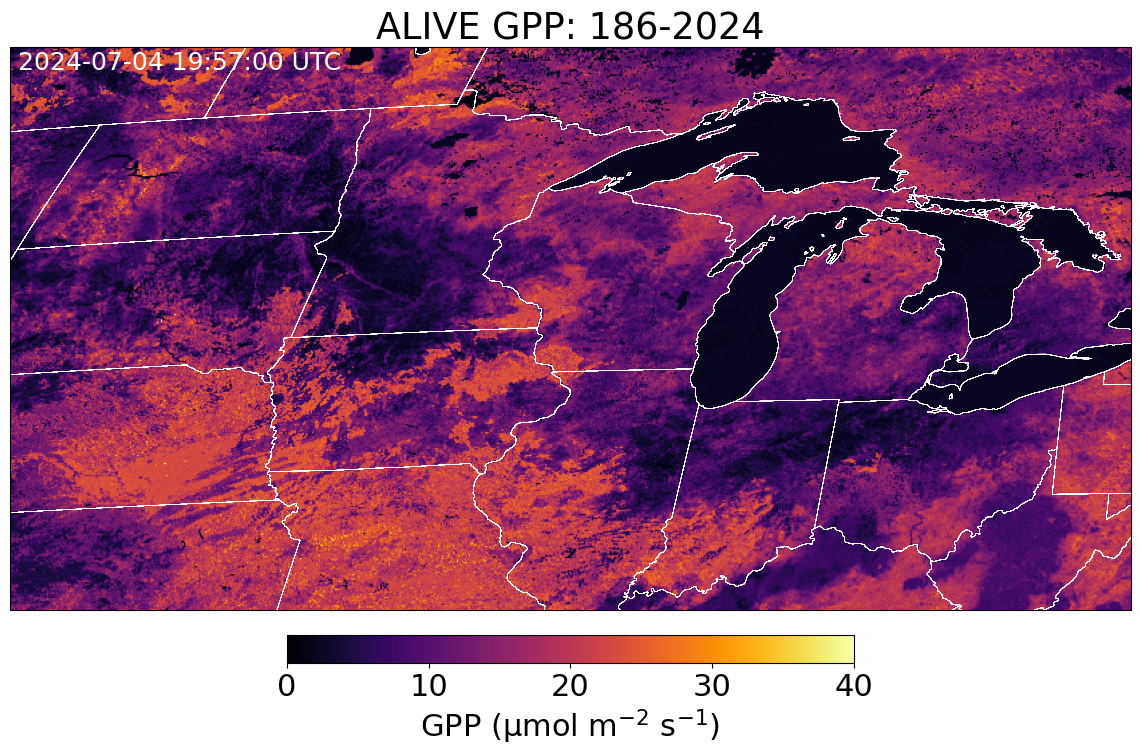

In [ ]:
start_time = time.time()
# Make ALIVE animation for day

#Set video visualization parameters
plt.rcParams['figure.figsize'] = [15, 15]
plt.rcParams['font.size'] = 22
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(1, 1, 1, projection=geostationary)
plt.title('ALIVE GPP: ' + str(start_doy) + '-' + str(year))
plt.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False)

#Loop through each timestamp in two-hour period
frames = []
oneframe = []
for timestamp in oneDay['t']:
    print(pd.to_datetime(timestamp.values).round('1s'))
    img = oneDay.sel(t=timestamp)
    im = ax.imshow(img, cmap=plt.cm.inferno, vmin = 0, vmax = 40, animated=True,
                   origin='upper',extent=(x.min(), x.max(), y.min(), y.max()), transform=geostationary)
    #Crop to the Midwestern region
    ax.set_extent([lat_west, lat_east, lon_south, lon_north], crs=ccrs.PlateCarree())

    # Add coastlines, states, and timestamp
    ax.coastlines(resolution='50m', color='white', linewidth=0.25)
    ax.add_feature(ccrs.cartopy.feature.STATES, edgecolor= 'white', linewidth=0.25)
    t = ax.annotate('{0} UTC'.format(pd.to_datetime(timestamp.values).round('1s')),(0.007,0.96), xycoords ='axes fraction', color = 'white', fontsize=18)
    oneframe = [im, t]
    frames.append(oneframe)

cb = fig.colorbar(im, label='GPP (μmol m$^{-2}$ s$^{-1}$)', orientation='horizontal', fraction=0.046, pad=0.04)

ani = animation.ArtistAnimation(fig, frames, interval=200, blit=True)
ani.save(path + loopName + '_ALIVE_GPP_{day}_{year}.mp4'.format(day=start_doy, year=year))

print('VIDEO')
print(float(time.time() - start_time) / 60 , 'minutes')

That concludes our lesson, we hope you enjoyed it!
